In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
import sys
print(sys.executable)

c:\Users\lujim\miniconda3\envs\cmapss\python.exe


In [5]:
cols = ['unit', 'cycle'] \
     + [f'op_setting_{i}' for i in range(1, 4)] \
     + [f'sensor_{i}' for i in range(1, 22)]

df = pd.read_csv('../data/CMaps/train_FD001.txt',
                 sep=r'\s+', header=None, names=cols)

df.head()

,unit,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [6]:
lifespans = df.groupby('unit')['cycle'].max()
lifespans

unit
1      192
2      287
3      179
4      189
5      269
      ... 
96     336
97     202
98     156
99     185
100    200
Name: cycle, Length: 100, dtype: int64

In [7]:
df.groupby('unit')['cycle'].max()

unit
1      192
2      287
3      179
4      189
5      269
      ... 
96     336
97     202
98     156
99     185
100    200
Name: cycle, Length: 100, dtype: int64

In [8]:
df[df['unit'] == 1].tail()

,unit,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
187,1,188,-0.0067,0.0003,100.0,518.67,643.75,1602.38,1422.78,14.62,...,519.79,2388.23,8117.69,8.5207,0.03,396,2388,100.0,38.51,22.9588
188,1,189,-0.0006,0.0002,100.0,518.67,644.18,1596.17,1428.01,14.62,...,519.58,2388.33,8117.51,8.5183,0.03,395,2388,100.0,38.48,23.1127
189,1,190,-0.0027,0.0001,100.0,518.67,643.64,1599.22,1425.95,14.62,...,520.04,2388.35,8112.58,8.5223,0.03,398,2388,100.0,38.49,23.0675
190,1,191,-0.0000,-0.0004,100.0,518.67,643.34,1602.36,1425.77,14.62,...,519.57,2388.30,8114.61,8.5174,0.03,394,2388,100.0,38.45,23.1295
191,1,192,0.0009,-0.0000,100.0,518.67,643.54,1601.41,1427.20,14.62,...,520.08,2388.32,8110.93,8.5113,0.03,396,2388,100.0,38.48,22.9649


In [9]:
lifespans.min()
lifespans.max()



np.int64(362)

In [10]:
lifespans.min()
lifespans.max()

np.int64(362)

In [11]:
print(lifespans.min())
print(lifespans.max())

128
362


In [12]:
lifespans

unit
1      192
2      287
3      179
4      189
5      269
      ... 
96     336
97     202
98     156
99     185
100    200
Name: cycle, Length: 100, dtype: int64

同一型号的发动机,寿命差了近三倍;如果按固定周期维护,定在 128 就对长寿发动机过度维修浪费钱,定得晚就让短命发动机带病上天。所以需要按每台发动机的实际状态预测寿命。

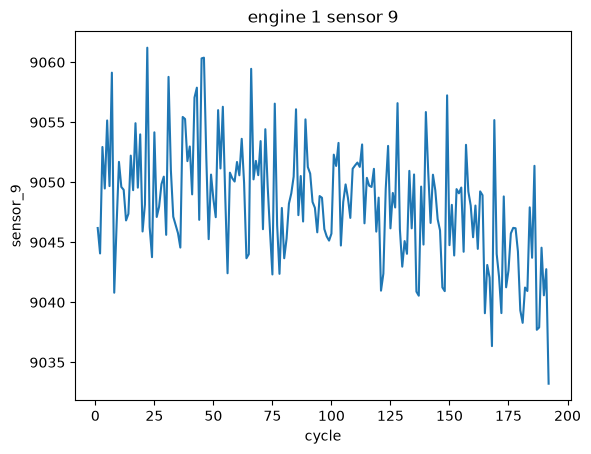

In [ ]:
engine1 = df[df['unit'] == 1] 
plt.plot(engine1['cycle'], engine1['sensor_9'])  
plt.xlabel('cycle')   
plt.ylabel('sensor_9')        
plt.title('engine 1 sensor 9')    
plt.show()              

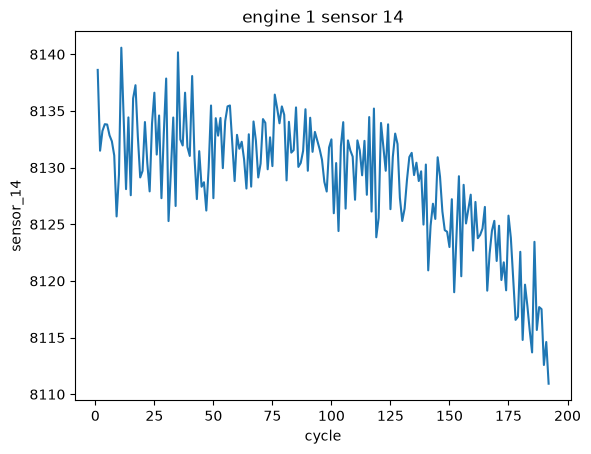

In [ ]:
engine1 = df[df['unit'] == 1]     
plt.plot(engine1['cycle'], engine1['sensor_14']) 
plt.xlabel('cycle')       
plt.ylabel('sensor_14')      
plt.title('engine 1 sensor 14')      
plt.show()          

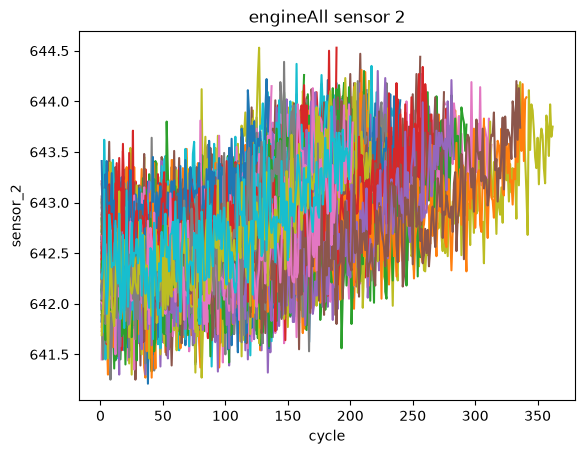

In [28]:
for i in lifespans.index:
    engineAll = df[df['unit'] == i]    
    plt.plot(engineAll['cycle'], engineAll['sensor_2'])
plt.xlabel('cycle')
plt.ylabel('sensor_2')
plt.title('engineAll sensor 2')
plt.show()

In [30]:
df.describe()

,unit,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,20631.00,20631.000000,20631.000000,20631.000000,2.063100e+04,...,20631.000000,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.0,20631.0,20631.000000,20631.000000
mean,51.506568,108.807862,-0.000009,0.000002,100.0,518.67,642.680934,1590.523119,1408.933782,1.462000e+01,...,521.413470,2388.096152,8143.752722,8.442146,3.000000e-02,393.210654,2388.0,100.0,38.816271,23.289705
std,29.227633,68.880990,0.002187,0.000293,0.0,0.00,0.500053,6.131150,9.000605,5.329200e-15,...,0.737553,0.071919,19.076176,0.037505,3.469531e-18,1.548763,0.0,0.0,0.180746,0.108251
min,1.000000,1.000000,-0.008700,-0.000600,100.0,518.67,641.210000,1571.040000,1382.250000,1.462000e+01,...,518.690000,2387.880000,8099.940000,8.324900,3.000000e-02,388.000000,2388.0,100.0,38.140000,22.894200
25%,26.000000,52.000000,-0.001500,-0.000200,100.0,518.67,642.325000,1586.260000,1402.360000,1.462000e+01,...,520.960000,2388.040000,8133.245000,8.414900,3.000000e-02,392.000000,2388.0,100.0,38.700000,23.221800
50%,52.000000,104.000000,0.000000,0.000000,100.0,518.67,642.640000,1590.100000,1408.040000,1.462000e+01,...,521.480000,2388.090000,8140.540000,8.438900,3.000000e-02,393.000000,2388.0,100.0,38.830000,23.297900
75%,77.000000,156.000000,0.001500,0.000300,100.0,518.67,643.000000,1594.380000,1414.555000,1.462000e+01,...,521.950000,2388.140000,8148.310000,8.465600,3.000000e-02,394.000000,2388.0,100.0,38.950000,23.366800
max,100.000000,362.000000,0.008700,0.000600,100.0,518.67,644.530000,1616.910000,1441.490000,1.462000e+01,...,523.380000,2388.560000,8293.720000,8.584800,3.000000e-02,400.000000,2388.0,100.0,39.430000,23.618400


In [ ]:
sensor_cols = cols[5:]           

early = df.groupby('unit').head(10)[sensor_cols].mean()
late  = df.groupby('unit').tail(10)[sensor_cols].mean()

trend = late - early
trend
up = trend[trend > 0]
down = trend [ trend <0 ]
nochange = trend [trend == 0]

print (up)
print (down )
print(nochange)


['sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21']
sensor_2      1.223570
sensor_3     14.636730
sensor_4     24.748790
sensor_6      0.000510
sensor_8      0.162460
sensor_9     39.548600
sensor_11     0.749210
sensor_13     0.166060
sensor_14    27.834780
sensor_15     0.097058
sensor_17     3.789000
dtype: float64
sensor_7    -2.330440
sensor_12   -1.991140
sensor_20   -0.464410
sensor_21   -0.278384
dtype: float64
sensor_1     0.0
sensor_5     0.0
sensor_10    0.0
sensor_16    0.0
sensor_18    0.0
sensor_19    0.0
dtype: float64


退化是双向的。11 个往上走(温度、压力类——机器带病运转,内部越来越热),4 个往下走(sensor_7、12 这些效率相关的量——性能衰减)。这符合物理直觉:发动机老化 = 热的更热、效的更低